In [1]:
%load_ext autoreload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib
from syd import Viewer
import os
from datetime import datetime

from scipy.signal import find_peaks
import scipy.signal as signal

from JR_test_scripts.escape.escape_utils import load_hdir_cells, load_significant_cells
from behave_analysis.utils.creating_directories import make_directory
from kilosort_SGLX_funcs.ProbeLocations.ProbeLocation_utils import reorder_colors_for_contrast, extract_subject_and_date, estimate_firing_rate
from kilosort_SGLX_funcs.SGLXMetaToCoords import readMeta
from kilosort_SGLX_funcs.SGLXMetaToCoords import MetaToCoords
from behave_analysis.process.process import Process

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

In [3]:
savepath = make_directory(r"Z:\Jasmine_Laurence\Histology\ChannelMap_to_Histology")

brainreg_base = Path(r"Z:\Jasmine_Laurence\Histology")

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, 
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [8]:
ss = "JAL4_3rdSept"
session = Process(experiments_objects[ss]).load_session()
session_folder = Path(session.base_path, session.file_path)
mouse_folder = Path(session.base_path, session.file_path.split("\\")[0])

s = os.path.normpath(session_folder).split("\\")[-1]
s = s.split("T")[-2]
s = s.split("_")[-3:]
sesh_date = datetime(int(s[0]), int(s[1]), int(s[2]))

survey_folders = [p for p in mouse_folder.glob("SvyPrb*") if p.is_dir()]
time_diff = np.zeros(len(survey_folders))
for srvy in survey_folders:
    s = os.path.normpath(srvy).split("_")[-2]
    s = s.split("T")[-2]
    s = s.split("-")
    srvy_date = datetime(int(s[0]), int(s[1]), int(s[2]))
    time_diff[survey_folders.index(srvy)] = (sesh_date - srvy_date).days

# check if the survey folder is the same as the last one, if so don't reload the data
survey_folder = []
if survey_folder == survey_folders[np.argmin(time_diff)]:
    print('blah')
else:
    survey_folder = survey_folders[np.argmin(time_diff)]

    # load the metadata
    metadata = readMeta(list(survey_folder.glob('*.meta'))[0])
    # load the probe survey data
    nChan = int(metadata['nSavedChans'])
    nFileSamp = int(int(metadata['fileSizeBytes'])/(2*nChan))
    rawData = np.memmap(list(survey_folder.glob('*.bin'))[0], dtype='int16', mode='r',
                        shape=(nChan, nFileSamp), offset=0, order='F')
    data = rawData.T

    # get the variance across channels
    v = np.var(data, axis = 1)

    # get bank transitions
    threshold = 150000
    session_str = str(ss)
    mouse = session_str.split('_')[0]
    if mouse == 'JAL8':
        threshold = 450000
    try:
        fs = int(metadata['imSampRate'])
    except ValueError:
        fs = int(float(metadata['imSampRate']))
    peaks, _ = find_peaks(np.diff(v), 
                                prominence=threshold, 
                                distance = fs*int(metadata['imSvySecPerBnk']))
    bank_breakpoints = np.concatenate(([int(metadata['firstSample'])], peaks, [len(v)]))
    bank_breakpoints_2 = bank_breakpoints[1:]
    bank_breakpoints = np.concatenate(([int(metadata['firstSample'])],bank_breakpoints_2[np.diff(bank_breakpoints) > 1]))
    assert len(bank_breakpoints) == 17, f"We now have {len(bank_breakpoints)} bank breakpoints and we should have 17"

    # load the data and compute FR
    offset = int(metadata['firstSample'])

    # set up the butter
    cutoff = [300, 7000]  # Cutoff frequency for low-pass filter in Hz (adjust as needed)
    order = 4     # Filter order (higher = sharper cutoff but more ringing)
    b, a = signal.butter(order, cutoff, btype='band', fs=fs)

    all_variances = []
    bank = 0
    shank = 0
    for (bb_start, bb_end) in zip(bank_breakpoints[:-1], bank_breakpoints[1:]):

        # stay far away from the edges of the banks
        if bb_end - bb_start < 3*fs:
            bb_start += (offset + (bb_end - bb_start) // 3)
            bb_end -= (bb_end - bb_start) // 3
        elif bb_end - bb_start > 3*fs:
            bb_start += (offset + fs) 
            bb_end -= fs
        
        # butter bandpass filter the data from this bank
        bank_data = data[int(bb_start):int(bb_end), :-1]
        filtered_data = np.zeros_like(bank_data)
        for i in range(bank_data.shape[1]):
            filtered_data[:, i] = signal.filtfilt(b, a, bank_data[:, i])

        # estimate firing rate
        firing_rates, _ = estimate_firing_rate(filtered_data, fs)
        
        all_variances.append({'bank': bank,
                                    'shank': shank,
                                    'FR': firing_rates.reshape((len(firing_rates)//2,2)),
                                    'filtered_data': filtered_data.reshape((filtered_data.shape[0], filtered_data.shape[1]//2, 2))}) # filtered data for this bank shaped as samples, channels, pads

        bank += 1
        if bank == 4:
            bank = 0
            shank += 1

2025-04-16 12:16:12.028 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


check: 0,4,5,6,8,10,12,15

2025-04-15 16:28:25.425 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


[     22   67413  164618  260018  362106  456293  552657  645666  747903
  844520  936914 1031308 1137747 1233746 1329672 1425025]
We now have 15 bank breakpoints and we should have 15


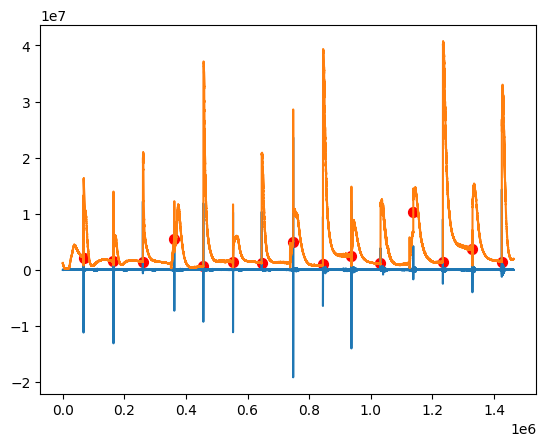

In [ ]:
threshold = 450000
e = list(experiments_objects.keys())
session = Process(experiments_objects[e[15]]).load_session()
session_folder = Path(session.base_path, session.file_path)
mouse_folder = Path(session.base_path, session.file_path.split("\\")[0])

s = os.path.normpath(session_folder).split("\\")[-1]
s = s.split("T")[-2]
s = s.split("_")[-3:]
sesh_date = datetime(int(s[0]), int(s[1]), int(s[2]))

survey_folders = [p for p in mouse_folder.glob("SvyPrb*") if p.is_dir()]
time_diff = np.zeros(len(survey_folders))
for srvy in survey_folders:
    s = os.path.normpath(srvy).split("_")[-2]
    s = s.split("T")[-2]
    s = s.split("-")
    srvy_date = datetime(int(s[0]), int(s[1]), int(s[2]))
    time_diff[survey_folders.index(srvy)] = (sesh_date - srvy_date).days

# check if the survey folder is the same as the last one, if so don't reload the data
survey_folder = []
if survey_folder == survey_folders[np.argmin(time_diff)]:
    print('blah')
else:
    survey_folder = survey_folders[np.argmin(time_diff)]

    # load the metadata
    # metadata = readMeta(list(survey_folder.glob('*.meta'))[0])
    # # load the probe survey data
    # nChan = int(metadata['nSavedChans'])
    # nFileSamp = int(int(metadata['fileSizeBytes'])/(2*nChan))
    # rawData = np.memmap(list(survey_folder.glob('*.bin'))[0], dtype='int16', mode='r',
    #                     shape=(nChan, nFileSamp), offset=0, order='F')
    # data = rawData.T

    # get the variance across channels
    v = np.var(data, axis = 1)
    try:
        fs = int(metadata['imSampRate'])
    except ValueError:
        fs = int(float(metadata['imSampRate']))
    peaks, _ = find_peaks(np.diff(v), 
                                prominence=threshold, 
                                distance = fs*int(metadata['imSvySecPerBnk']))
    plt.plot(np.diff(v))
    plt.plot(v)
    plt.scatter(peaks, v[peaks], color='red', s=50)
    bank_breakpoints = np.concatenate(([int(metadata['firstSample'])], peaks))
    bank_breakpoints_2 = bank_breakpoints[1:]
    bank_breakpoints = bank_breakpoints_2[np.diff(bank_breakpoints) > 1]
    print(f"We now have {len(bank_breakpoints)} bank breakpoints and we should have 15")
    if len(bank_breakpoints) > 15:
        print('yes')
        # check that we don't have breakpoints at odd spacings (too close together)
        bb = np.concatenate(([int(metadata['firstSample'])], bank_breakpoints))
        bad_idx = np.where(np.diff(bb) > (np.mean(np.diff(bb))-np.std(np.diff(bb))))[0]
        print(bank_breakpoints)
        print(np.diff(bank_breakpoints))
        print(bad_idx)
        bank_breakpoints = bank_breakpoints[bad_idx]
    # bank_breakpoints = np.concatenate(([int(metadata['firstSample'])],bank_breakpoints_2[np.diff(bank_breakpoints) > 1], len(v)))


In [9]:
e = list(experiments_objects.keys())
sessy = e[9]
session = Process(experiments_objects[sessy]).load_session()
session_folder = Path(session.base_path, session.file_path)
mouse_folder = Path(session.base_path, session.file_path.split("\\")[0])
g0_folders = [p for p in session_folder.glob("*g0") if p.is_dir()]
ephys_path = Path(g0_folders[0], os.path.normpath(g0_folders[0]).split(os.sep)[-1] + "_imec0")
# # --- Load core data ---
KS_path = Path(ephys_path, "SI_KS_output", "sorter_output")
channel_positions = np.load(Path(KS_path, 'channel_positions.npy'))  # (n_clusters,)

# Extract the good clusters and their channels
if Path(KS_path, 'cluster_info.tsv').exists():
    clusters_inf = pd.read_csv(Path(KS_path, 'cluster_info.tsv'), sep='\t')
    if "group" in clusters_inf.columns:
        good_clusters = clusters_inf[clusters_inf['group'] == 'good']
    else:
        good_clusters = clusters_inf[clusters_inf['KSLabel'] == "good"]
    ch = good_clusters["ch"]
else:
    templates = np.load(Path(KS_path, 'templates.npy'))
    cluster_ch = np.argmin(np.amin(templates, axis = 1), axis = 1)
    KSlabel = pd.read_csv(Path(KS_path, 'cluster_KSLabel.tsv'), sep='\t')
    good_clusters = KSlabel[KSlabel['KSLabel'] == 'good']
    ch = cluster_ch[good_clusters['cluster_id']]

# load hdir cells
hdir = np.full((len(ch)), False)
hdir_sesh = load_hdir_cells([experiments_objects[sessy]],[sessy])
hdir[hdir_sesh[0]] = True

# load cells sig tuned to %escape
sig = load_significant_cells(experiments_objects[sessy])
sig = np.sum(sig, axis = 1) > 0

# build a pandas df
df = pd.DataFrame({'ch': ch, 
                   'ch_x': channel_positions[ch, 0],
                   'ch_y': channel_positions[ch, 1],
                   'hdir': hdir, 
                   'sig': sig,
                   'clu_id': good_clusters['cluster_id']})

exp_name = os.path.normpath(ephys_path).split(os.sep)[-2]
meta_path = Path(ephys_path, exp_name + "_t0.imec0.ap.meta")

# read the meta file
_, yCoord, shankInd, _, _ = MetaToCoords(metaFullPath=meta_path, outType=0, showPlot=False)

# get the bank positions
channel_spacing = 15
bank_positions = []
bank_shanks = []
for i in np.unique(shankInd):
    these_y = np.unique(yCoord[shankInd == i])
    bb = np.where(np.diff(these_y) > channel_spacing)[0]
    if len(bb) == 0:
        bank_positions.append([these_y[0], these_y[-1]])
        bank_shanks.append(i)
    else:
        bb = np.concatenate(([0], bb + 1, [len(these_y)-1]))
        for j in range(len(bb)-1):
            bank_positions.append([these_y[bb[j]], these_y[bb[j+1]-1]])
            bank_shanks.append(i)
bank_positions = np.array(bank_positions)
bank_shanks = np.array(bank_shanks)

2025-04-16 12:31:02.042 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2025-04-16 12:31:02.464 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [16]:
i = 0
ch_x = [  0.,  32., 250., 282., 500., 532., 750., 782.]
bank_x = [-.1, .1, .9, 1.1, 1.9, 2.1, 2.9, 3.1]
for i in df['ch'].to_numpy():
    bank_x[np.where(ch_x == channel_positions[i,0])[0][0]]
    

In [7]:
class ProbeViewer(Viewer):
    def __init__(self, num_shanks):

        # Initialize the Viewer
        self.num_shanks = num_shanks
        self.mouse = [] # initialize mouse variable
        self.survey_folder = [] # initialize survey folder variable
        self.channel_spacing = 15  # µm spacing between channels

        # add viewer parameters
        self.add_float("scale", value=3, min=0, max=5)
        # parameters for the brainreg probe map
        self.add_selection('Session', value = list(experiments_objects.keys())[2], options = list(experiments_objects.keys()))
        self.add_selection('Colormap', value = 'tab20b', options = ['tab20b'])
        self.add_boolean('show_hdir', value = True)
        self.add_boolean('show_nonsig', value = True)
        # parameters for the survey data
        self.add_float('survey_ylim_mm', value = 3, min=0, max=11.520) # 11.520 is the max depth of the probe in mm
        # parameters for the trace viewer
        self.add_selection('shank', value = 0, options = [0, 1, 2, 3])
        self.add_text('depth_um', value = '450') # add_integer
        self.add_float('num_traces', value = 10, min = 1, max = 50, step = 1)
        self.add_float_range('x_range_s', value = [.6, .8], min = 0, max = 2, step = .1) # add_integer_range 
        self.add_float('spacing_au', value = 300, min = 0, max = 1000, step = 100) # add_integer
        # for output saving
        self.add_button('savefig', label='Save Figure', callback=self.save_fig)
        self.add_button('savedf', label='Save Data', callback=self.save_df)
    
    def make_colormap(self, state):
        # Create a custom colormap with distinct colors for each region
        tab20b_cmap = matplotlib.colormaps.get_cmap(state['Colormap'])
        tab20b_colors = [tab20b_cmap(i) for i in range(20)]
        optimized_colors = reorder_colors_for_contrast(tab20b_colors, self.num_colors)
        # Create custom colormap
        custom_cmap = mcolors.ListedColormap(optimized_colors)
        # Create a normalization that maps each integer to a different color
        cmap_norm = mcolors.Normalize(vmin=-0.5, vmax=self.num_colors-0.5)
        return custom_cmap, cmap_norm

    def load_tracks(self, state):
        # Load in the coordinates of the tracks
        self.mouse = state['Session'][:4]
        brainreg_path = Path(brainreg_base, "MouseID_00" + self.mouse[3], "brainreg", "segmentation", "atlas_space", "tracks")
        for i in range(4):
            track_path = Path(brainreg_path, f'track_{i}.csv')
            # Load in coordinates of track in CCF space (order - apdvml, origin - top, left, front voxel
            xyz = pd.read_csv(track_path)
            if i == 0:
                df = xyz
            else:
                df = pd.concat([df, xyz], ignore_index=True)

        regions = df['Region acronym']
        region_codes, self.unique_regions = pd.factorize(regions)  # Convert regions to integer codes

        self.region_by_probe = region_codes.reshape((self.num_shanks, len(region_codes)//self.num_shanks))
        self.region_by_probe = np.fliplr(self.region_by_probe)
    
    def load_clusters(self, state):
        # plot all good clusters or only clusters that are sig tuned to %escape

        # # --- Load core data ---
        KS_path = Path(self.ephys_path, "SI_KS_output", "sorter_output")
        self.channel_positions = np.load(Path(KS_path, 'channel_positions.npy'))  # (n_clusters,)

        # Extract the good clusters and their channels
        if Path(KS_path, 'cluster_info.tsv').exists():
            clusters_inf = pd.read_csv(Path(KS_path, 'cluster_info.tsv'), sep='\t')
            if "group" in clusters_inf.columns:
                good_clusters = clusters_inf[clusters_inf['group'] == 'good']
            else:
                good_clusters = clusters_inf[clusters_inf['KSLabel'] == "good"]
            ch = good_clusters["ch"]
        else:
            templates = np.load(Path(KS_path, 'templates.npy'))
            cluster_ch = np.argmin(np.amin(templates, axis = 1), axis = 1)
            KSlabel = pd.read_csv(Path(KS_path, 'cluster_KSLabel.tsv'), sep='\t')
            good_clusters = KSlabel[KSlabel['KSLabel'] == 'good']
            ch = cluster_ch[good_clusters['cluster_id']]

        # load hdir cells
        hdir = np.full((len(ch)), False)
        hdir_sesh = load_hdir_cells([experiments_objects[state['Session']]],[state['Session']])
        hdir[hdir_sesh[0]] = True

        # load cells sig tuned to %escape
        sig = load_significant_cells(experiments_objects[state['Session']])
        sig = np.sum(sig, axis = 1) > 0

        # build a pandas df
        self.df = pd.DataFrame({'ch': ch, 
                                'ch_x': self.channel_positions[ch, 0],
                                'ch_y': self.channel_positions[ch, 1],
                                'hdir': hdir, 
                                'sig': sig,
                                'clu_id': good_clusters['cluster_id']})

    def load_channel_map(self, state):
        # recording meta path - where the channel map is stored
        exp_name = os.path.normpath(self.ephys_path).split(os.sep)[-2]
        meta_path = Path(self.ephys_path, exp_name + "_t0.imec0.ap.meta")

        # read the meta file
        _, yCoord, self.shankInd, _, _ = MetaToCoords(metaFullPath=meta_path, outType=0, showPlot=False)

        # get the bank positions
        bank_positions = []
        bank_shanks = []
        for i in np.unique(self.shankInd):
            these_y = np.unique(yCoord[self.shankInd == i])
            bb = np.where(np.diff(these_y) > self.channel_spacing)[0]
            if len(bb) == 0:
                bank_positions.append([these_y[0], these_y[-1]])
                bank_shanks.append(i)
            else:
                bb = np.concatenate(([0], bb + 1, [len(these_y)-1]))
                for j in range(len(bb)-1):
                    bank_positions.append([these_y[bb[j]], these_y[bb[j+1]-1]])
                    bank_shanks.append(i)
        self.bank_positions = np.array(bank_positions)
        self.bank_shanks = np.array(bank_shanks)

    def load_survey(self, state):
        
        # initialize the survey vars
        self.n_channels_per_srvy_bank = 384/2
        self.bank_vertical_size = self.channel_spacing * self.n_channels_per_srvy_bank

        # find the survey path by comparing the date of the survey to the date of the recording
        s = os.path.normpath(self.session_folder).split("\\")[-1]
        s = s.split("T")[-2]
        s = s.split("_")[-3:]
        sesh_date = datetime(int(s[0]), int(s[1]), int(s[2]))

        survey_folders = [p for p in self.mouse_folder.glob("SvyPrb*") if p.is_dir()]
        time_diff = np.zeros(len(survey_folders))
        for srvy in survey_folders:
            s = os.path.normpath(srvy).split("_")[-2]
            s = s.split("T")[-2]
            s = s.split("-")
            srvy_date = datetime(int(s[0]), int(s[1]), int(s[2]))
            time_diff[survey_folders.index(srvy)] = (sesh_date - srvy_date).days

        # check if the survey folder is the same as the last one, if so don't reload the data
        if self.survey_folder == survey_folders[np.argmin(time_diff)]:
            return
        else:
            self.survey_folder = survey_folders[np.argmin(time_diff)]

            # load the metadata
            metadata = readMeta(list(self.survey_folder.glob('*.meta'))[0])

            # load the probe survey data
            nChan = int(metadata['nSavedChans'])
            nFileSamp = int(int(metadata['fileSizeBytes'])/(2*nChan))
            rawData = np.memmap(list(self.survey_folder.glob('*.bin'))[0], dtype='int16', mode='r',
                                shape=(nChan, nFileSamp), offset=0, order='F')
            data = rawData.T

            # get the variance across channels
            v = np.var(data, axis = 1)

            # get bank transitions
            threshold = 150000
            if self.mouse == 'JAL8':
                threshold = 450000
            try:
                self.fs = int(metadata['imSampRate'])
            except ValueError:
                self.fs = int(float(metadata['imSampRate']))
            peaks, _ = find_peaks(np.diff(v), 
                                        prominence=threshold, 
                                        distance = self.fs*int(metadata['imSvySecPerBnk']))
            bank_breakpoints = np.concatenate(([int(metadata['firstSample'])], peaks, [len(v)]))
            bank_breakpoints_2 = bank_breakpoints[1:]
            bank_breakpoints = np.concatenate(([int(metadata['firstSample'])],bank_breakpoints_2[np.diff(bank_breakpoints) > 1]))
            assert len(bank_breakpoints) == 17, f"We now have {len(bank_breakpoints)} bank breakpoints and we should have 17"

            # load the data and compute FR
            offset = int(metadata['firstSample'])

            # set up the butter
            cutoff = [300, 7000]  # Cutoff frequency for low-pass filter in Hz (adjust as needed)
            order = 4     # Filter order (higher = sharper cutoff but more ringing)
            b, a = signal.butter(order, cutoff, btype='band', fs=self.fs)

            self.all_variances = []
            bank = 0
            shank = 0
            for (bb_start, bb_end) in zip(bank_breakpoints[:-1], bank_breakpoints[1:]):

                # stay far away from the edges of the banks
                if bb_end - bb_start < (3*self.fs):
                    bb_start += (offset + (bb_end - bb_start) // 3)
                    bb_end -= (bb_end - bb_start) // 3
                elif bb_end - bb_start > (3*self.fs):
                    bb_start += (offset + (self.fs)) 
                    bb_end -= (self.fs)
                
                # butter bandpass filter the data from this bank
                bank_data = data[int(bb_start):int(bb_end), :-1]
                filtered_data = np.zeros_like(bank_data)
                for i in range(bank_data.shape[1]):
                    filtered_data[:, i] = signal.filtfilt(b, a, bank_data[:, i])

                # estimate firing rate
                firing_rates, _ = estimate_firing_rate(filtered_data, self.fs)
                
                self.all_variances.append({'bank': bank,
                                           'shank': shank,
                                           'FR': firing_rates.reshape((len(firing_rates)//2,2)),
                                           'filtered_data': filtered_data.reshape((filtered_data.shape[0], filtered_data.shape[1]//2, 2))}) # filtered data for this bank shaped as samples, channels, pads

                bank += 1
                if bank == 4:
                    bank = 0
                    shank += 1

    def load_data(self, state):
        
        # if changing mouse, load in the brianreg probe map
        session_str = str(state['Session'])
        mouse_id = session_str.split('_')[0]
        if not self.mouse or mouse_id != self.mouse:
            self.load_tracks(state)
            self.mouse = mouse_id

        # define the path for the session ephys
        session = Process(experiments_objects[state['Session']]).load_session()
        self.session_folder = Path(session.base_path, session.file_path)
        self.mouse_folder = Path(session.base_path, session.file_path.split("\\")[0])
        g0_folders = [p for p in self.session_folder.glob("*g0") if p.is_dir()]
        self.ephys_path = Path(g0_folders[0], os.path.normpath(g0_folders[0]).split(os.sep)[-1] + "_imec0")

        # load in the survey data
        self.load_survey(state)

        # load in channel map
        self.load_channel_map(state)

        # load in the clusters
        self.load_clusters(state)
    
    def plot(self,state):
        
        self.load_data(state)
        
        # make the colormap
        self.num_colors = len(self.unique_regions)
        custom_cmap, norm = self.make_colormap(state)

        # make the figure
        fig = plt.figure(figsize=(10, 15))
        gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1], height_ratios=[4, 1, 1])

        # probe histology map
        axs = fig.add_subplot(gs[0, 0])
        axs.imshow(self.region_by_probe.T, aspect='auto', cmap=custom_cmap, norm=norm, interpolation = "none")
        axs.set_xticks([0,1,2,3])
        axs.set_xticklabels(['Shank1', 'Shank2', 'Shank3', 'Shank4'])
        axs.set_yticks([])

        for i, region in enumerate(self.unique_regions):
            if region == "Not found in brain":
                continue
            x_pos = np.argmax(np.sum(self.region_by_probe == i, axis=1))
            y_pos = np.mean(np.where(self.region_by_probe[x_pos,:] == i)[0])
            axs.text(x_pos, y_pos, region, ha='center', va='center', fontsize=8, color='black', weight = 'bold')
        
        # add the channel map using bank positions
        for (bs, bp) in zip(self.bank_shanks,self.bank_positions):
            axs.plot([bs-0.15, bs+0.15], [bp[1]/state['scale'], bp[1]/state['scale']], color='red', linewidth=1)  # Draw a line for the bank
            axs.plot([bs-0.15, bs+0.15], [bp[0]/state['scale'], bp[0]/state['scale']], color='red', linewidth=1)  # Draw a line for the bank
            axs.plot([bs-0.15, bs-0.15], [bp[0]/state['scale'], bp[1]/state['scale']], color='red', linewidth=1)  # Draw a line for the bank
            axs.plot([bs+0.15, bs+0.15], [bp[0]/state['scale'], bp[1]/state['scale']], color='red', linewidth=1)  # Draw a line for the bank

        # add the good cluster locations
        ch_x = [  0.,  32., 250., 282., 500., 532., 750., 782.]
        ch_x_beta = [ 27.,  59., 277., 309., 527., 559., 777., 809.] # older probe configs
        bank_x = [-.1, .1, .9, 1.1, 1.9, 2.1, 2.9, 3.1]

        for clu, i in enumerate(self.df['ch'].to_numpy()):
            color = 'white' # default color - indicating a cell that is significant and not hdir
            # do you want to plot hdir cells?
            if self.df['hdir'].to_numpy()[clu]:
                color = 'red'
                if not state['show_hdir']:
                    continue

            # do you want to plot non-significant cells?
            if (not self.df['sig'].to_numpy()[clu]) & (not self.df['hdir'].to_numpy()[clu]):
                color = 'black'
                if not state['show_nonsig']:
                    continue

            x = bank_x[np.where((ch_x == self.channel_positions[i,0]) | (ch_x_beta == self.channel_positions[i,0]))[0][0]]
            axs.scatter(x, self.channel_positions[i,1]/state['scale'], 
                    facecolors='none',  # Makes markers hollow/unfilled
                    edgecolors=color,  # Sets the edge color
                    s=20, marker='o', alpha = .7, linewidths=1)
    
        axs.invert_yaxis()

        # add the subplot with the survey data
        axs = fig.add_subplot(gs[0,1])
        shank = self.all_variances[0]['shank']
        x = [-.25,.25]
        for shank in range(self.num_shanks):
            for bank in self.all_variances:
                if bank['shank'] == shank:
                    if bank['bank'] == 0:
                        fr = bank['FR']
                    else:
                        fr = np.concatenate((fr, bank['FR']), axis = 0)
                if shank == 3:
                    bank_id = bank['bank']
                    bank_vertical_size = len(bank['FR'])
                    bank_x_position = bank['shank']
                    bank_y_start = bank_id * bank_vertical_size
                    axs.plot([bank_x_position-0.25, bank_x_position+0.25], [bank_y_start, bank_y_start], color='red', linewidth=1)  # Draw a line for the bank
                    axs.plot([bank_x_position-0.25, bank_x_position+0.25], [bank_y_start + bank_vertical_size, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
                    axs.plot([bank_x_position-0.25, bank_x_position-0.25], [bank_y_start, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
                    axs.plot([bank_x_position+0.25, bank_x_position+0.25], [bank_y_start, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
            axs.imshow(fr, aspect='auto', cmap='Greys', interpolation='none', extent = [x[0], x[1], fr.shape[0], 0])
            x = [x+1 for x in x]

        # add the channel map using bank positions
        for (bs, bp) in zip(self.bank_shanks,self.bank_positions):
            bp = [x/self.channel_spacing for x in bp]
            axs.plot([bs-0.2, bs+0.2], [bp[1], bp[1]], color='blue', linewidth=1)  # Draw a line for the bank
            axs.plot([bs-0.2, bs+0.2], [bp[0], bp[0]], color='blue', linewidth=1)  # Draw a line for the bank
            axs.plot([bs-0.2, bs-0.2], [bp[0], bp[1]], color='blue', linewidth=1)  # Draw a line for the bank
            axs.plot([bs+0.2, bs+0.2], [bp[0], bp[1]], color='blue', linewidth=1)  # Draw a line for the bank

        axs.set_xlim(-1, 4)
        tick_space_um = 300
        axs.set_yticks(np.arange(0, 1000*state['survey_ylim_mm']/self.channel_spacing, tick_space_um/self.channel_spacing))
        axs.set_yticklabels(np.arange(0, 1000*state['survey_ylim_mm'] , tick_space_um))
        axs.set_ylim(-1, (1000*state['survey_ylim_mm']/self.channel_spacing)+1)
        axs.set_ylabel('Depth (um)')
        # show colorbar
        cbar = fig.colorbar(axs.get_children()[0], ax=axs)

        # add the subplot for trace viewing
        contact_call = int(state['depth_um']) / self.channel_spacing
        contact_num = 0
        for shank in self.all_variances:
            if shank['shank'] == state['shank']:
                if (contact_call < (contact_num + shank['FR'].shape[0])) & (contact_call > contact_num):
                    c = int(contact_call - contact_num) # this is the number of the electrode in the bank
                    # how many traces on either side
                    if np.remainder(state['num_traces'], 2) == 0:
                        num_trace = [int(state['num_traces'] / 2), int(state['num_traces'] / 2)]
                    else:
                        num_trace = [int(state['num_traces'] / 2) + 1, int(state['num_traces'] / 2)]
                    for i in range(2):
                        axs = fig.add_subplot(gs[1+i, :])
                        x = np.arange(0, len(shank['filtered_data'][:, c, i])/30000, 1/30000)
                        ytick = []
                        yticklabel = []
                        for cc, c_idx in enumerate(range(c-num_trace[0], c+num_trace[1])):
                            if c_idx < 0 or c_idx >= shank['filtered_data'].shape[1]:
                                continue
                            axs.plot(x, shank['filtered_data'][:, c_idx, i]+(state['spacing_au']*cc), color = 'black')
                            ytick.append(300*cc)
                            yticklabel.append(int(state['depth_um']) + (c_idx - c)*self.channel_spacing)
                        axs.set_xlim(state['x_range_s'])
                        axs.set_xlabel('Time (s)')
                        axs.set_yticks(ytick)
                        axs.set_yticklabels(yticklabel)
                        axs.set_ylabel('Depth (um)')
                    break
                contact_num += shank['FR'].shape[0]
        
        self.fig = fig
        
        return fig
    
    """Callback functions"""
    def save_fig(self, state):
        # Save the figure
        self.fig.savefig(os.path.join(savepath, f"{state['Session']}_probe_map_scale_{state['scale']:.2f}.png"), dpi=300)

    def save_df(self, state):
        # map the clusters to the brainreg probe locations
        self.df['ch_y_scales'] = (self.df['ch_y'] / state['scale']).astype(int)
        self.df['ch_shank'] = (self.shankInd[self.df['ch']]).astype(int)
        region_by_cluster = []
        for x,y in zip(self.df['ch_shank'], self.df['ch_y_scales']):
            if y > 1000:
                region_by_cluster.append('Not found in brain')
            else:
                region_by_cluster.append(self.unique_regions[self.region_by_probe[x, y]])
        self.df['region'] = region_by_cluster
        # Save the dataframe
        self.df.to_csv(os.path.join(savepath, f"{state['Session']}_probe_map_scale_{state['scale']:.2f}.csv"), index=False)


In [8]:
%matplotlib inline
env = "notebook"
viewer = ProbeViewer(num_shanks = 4).deploy(env=env, continuous = False)

2025-04-24 12:04:05.378 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2025-04-24 12:13:51.495 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
